# Predicting Chronic Kidney Disease

## Loading Dataset

**Source:** Kaggle – Kidney Disease Dataset  
**Dataset URL:** https://www.kaggle.com/datasets/amanik000/kidney-disease-dataset

In [ ]:
import pandas as pd

df = pd.read_csv(
    "../../assets/datasets/2_KG_Kidney_Disease_Dataset/data/kidney_disease_dataset.csv"
)

df.head()

,Age of the patient,Blood pressure (mm/Hg),Specific gravity of urine,Albumin in urine,Sugar in urine,Red blood cells in urine,Pus cells in urine,Pus cell clumps in urine,Bacteria in urine,Random blood glucose level (mg/dl),...,Smoking status,Body Mass Index (BMI),Physical activity level,Duration of diabetes mellitus (years),Duration of hypertension (years),Cystatin C level,Urinary sediment microscopy results,C-reactive protein (CRP) level,Interleukin-6 (IL-6) level,Target
0,54,167,1.023,1,4,normal,abnormal,not present,not present,96,...,yes,25.3,low,4,16,0.67,normal,4.88,10.23,No_Disease
1,42,127,1.023,3,2,normal,normal,not present,present,73,...,no,20.6,moderate,3,13,0.55,abnormal,4.49,13.11,Low_Risk
2,38,148,1.016,0,0,abnormal,normal,not present,not present,77,...,no,38.4,high,11,23,2.37,abnormal,4.57,13.27,No_Disease
3,7,98,1.017,4,0,abnormal,normal,not present,present,225,...,no,24.7,high,24,3,2.54,abnormal,8.57,12.36,No_Disease
4,67,174,1.015,1,1,normal,abnormal,not present,not present,376,...,yes,17.6,high,22,24,1.90,normal,6.75,1.46,No_Disease


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20538 entries, 0 to 20537
Data columns (total 43 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Age of the patient                           20538 non-null  int64  
 1   Blood pressure (mm/Hg)                       20538 non-null  int64  
 2   Specific gravity of urine                    20538 non-null  float64
 3   Albumin in urine                             20538 non-null  int64  
 4   Sugar in urine                               20538 non-null  int64  
 5   Red blood cells in urine                     20538 non-null  str    
 6   Pus cells in urine                           20538 non-null  str    
 7   Pus cell clumps in urine                     20538 non-null  str    
 8   Bacteria in urine                            20538 non-null  str    
 9   Random blood glucose level (mg/dl)           20538 non-null  int64  
 10  Blood ure

In [10]:
df.isnull().sum()

Age of the patient                             0
Blood pressure (mm/Hg)                         0
Specific gravity of urine                      0
Albumin in urine                               0
Sugar in urine                                 0
Red blood cells in urine                       0
Pus cells in urine                             0
Pus cell clumps in urine                       0
Bacteria in urine                              0
Random blood glucose level (mg/dl)             0
Blood urea (mg/dl)                             0
Serum creatinine (mg/dl)                       0
Sodium level (mEq/L)                           0
Potassium level (mEq/L)                        0
Hemoglobin level (gms)                         0
Packed cell volume (%)                         0
White blood cell count (cells/cumm)            0
Red blood cell count (millions/cumm)           0
Hypertension (yes/no)                          0
Diabetes mellitus (yes/no)                     0
Coronary artery dise

**Observation**

The dataset contains no missing values across all 43 columns. Therefore, no missing-value imputation is required during preprocessing.

In [11]:
df.duplicated().sum()

np.int64(0)

**Observation**

The dataset contains 0 duplicate records. Therefore, no duplicate rows need to be removed.

## Data Preprocessing

In [12]:
df.select_dtypes(include='str').nunique()

Red blood cells in urine                    2
Pus cells in urine                          2
Pus cell clumps in urine                    2
Bacteria in urine                           2
Hypertension (yes/no)                       2
Diabetes mellitus (yes/no)                  2
Coronary artery disease (yes/no)            2
Appetite (good/poor)                        2
Pedal edema (yes/no)                        2
Anemia (yes/no)                             2
Family history of chronic kidney disease    2
Smoking status                              2
Physical activity level                     3
Urinary sediment microscopy results         2
Target                                      5
dtype: int64

**Observation**

The dataset contains 15 categorical variables. Most are binary variables, while Physical activity level contains three categories and Target contains five classes. These categorical variables will need to be encoded before model training.

In [13]:
df.select_dtypes(include='str').apply(lambda x: x.unique())

Red blood cells in urine                                                   [normal, abnormal]
Pus cells in urine                                                         [abnormal, normal]
Pus cell clumps in urine                                               [not present, present]
Bacteria in urine                                                      [not present, present]
Hypertension (yes/no)                                                               [yes, no]
Diabetes mellitus (yes/no)                                                          [yes, no]
Coronary artery disease (yes/no)                                                    [no, yes]
Appetite (good/poor)                                                             [good, poor]
Pedal edema (yes/no)                                                                [no, yes]
Anemia (yes/no)                                                                     [no, yes]
Family history of chronic kidney disease                    

## 2.1 Encoding Categorical Variables

Categorical variables are converted into numerical representations so that they can be used by machine learning algorithms.

In [14]:
df_processed = df.copy()

### Binary Categorical Encoding

The binary categorical variables are converted into numerical values, where the two categories are represented by 0 and 1.

In [15]:
binary_columns = [
    'Red blood cells in urine',
    'Pus cells in urine',
    'Pus cell clumps in urine',
    'Bacteria in urine',
    'Hypertension (yes/no)',
    'Diabetes mellitus (yes/no)',
    'Coronary artery disease (yes/no)',
    'Appetite (good/poor)',
    'Pedal edema (yes/no)',
    'Anemia (yes/no)',
    'Family history of chronic kidney disease',
    'Smoking status',
    'Urinary sediment microscopy results'
]

for col in binary_columns:
    df_processed[col] = df_processed[col].astype('category').cat.codes

In [16]:
df_processed[binary_columns].head()

,Red blood cells in urine,Pus cells in urine,Pus cell clumps in urine,Bacteria in urine,Hypertension (yes/no),Diabetes mellitus (yes/no),Coronary artery disease (yes/no),Appetite (good/poor),Pedal edema (yes/no),Anemia (yes/no),Family history of chronic kidney disease,Smoking status,Urinary sediment microscopy results
0,1,0,0,0,1,1,0,0,0,0,0,1,1
1,1,1,0,1,0,1,0,0,1,1,1,0,0
2,0,1,0,0,0,0,1,0,1,0,0,0,0
3,0,1,0,1,0,0,1,0,0,1,0,0,0
4,1,0,0,0,0,0,0,0,1,1,0,1,1


### Encoding Physical Activity Level

The `Physical activity level` variable contains three categories: low, moderate, and high. One-hot encoding is used to represent these categories numerically without assuming an order between them.

In [17]:
df_processed = pd.get_dummies(
    df_processed,
    columns=['Physical activity level'],
    dtype=int
)

In [18]:
df_processed.head()

,Age of the patient,Blood pressure (mm/Hg),Specific gravity of urine,Albumin in urine,Sugar in urine,Red blood cells in urine,Pus cells in urine,Pus cell clumps in urine,Bacteria in urine,Random blood glucose level (mg/dl),...,Duration of diabetes mellitus (years),Duration of hypertension (years),Cystatin C level,Urinary sediment microscopy results,C-reactive protein (CRP) level,Interleukin-6 (IL-6) level,Target,Physical activity level_high,Physical activity level_low,Physical activity level_moderate
0,54,167,1.023,1,4,1,0,0,0,96,...,4,16,0.67,1,4.88,10.23,No_Disease,0,1,0
1,42,127,1.023,3,2,1,1,0,1,73,...,3,13,0.55,0,4.49,13.11,Low_Risk,0,0,1
2,38,148,1.016,0,0,0,1,0,0,77,...,11,23,2.37,0,4.57,13.27,No_Disease,1,0,0
3,7,98,1.017,4,0,0,1,0,1,225,...,24,3,2.54,0,8.57,12.36,No_Disease,1,0,0
4,67,174,1.015,1,1,1,0,0,0,376,...,22,24,1.90,1,6.75,1.46,No_Disease,1,0,0


### Encoding the Target Variable

The target variable contains five kidney disease risk classes. These categorical labels are converted into numerical values so that they can be used as the output variable during model training.

In [20]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df_processed['Target'] = label_encoder.fit_transform(df_processed['Target'])

In [21]:
print(dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

{'High_Risk': np.int64(0), 'Low_Risk': np.int64(1), 'Moderate_Risk': np.int64(2), 'No_Disease': np.int64(3), 'Severe_Disease': np.int64(4)}


**Observation**

The five target classes were successfully converted into numerical labels using LabelEncoder. Each kidney disease risk category is now represented by a unique numerical value, which can be used as the target variable during model training.

In [22]:
df_processed.info()

<class 'pandas.DataFrame'>
RangeIndex: 20538 entries, 0 to 20537
Data columns (total 45 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Age of the patient                           20538 non-null  int64  
 1   Blood pressure (mm/Hg)                       20538 non-null  int64  
 2   Specific gravity of urine                    20538 non-null  float64
 3   Albumin in urine                             20538 non-null  int64  
 4   Sugar in urine                               20538 non-null  int64  
 5   Red blood cells in urine                     20538 non-null  int8   
 6   Pus cells in urine                           20538 non-null  int8   
 7   Pus cell clumps in urine                     20538 non-null  int8   
 8   Bacteria in urine                            20538 non-null  int8   
 9   Random blood glucose level (mg/dl)           20538 non-null  int64  
 10  Blood ure

In [23]:
df_processed.head()

,Age of the patient,Blood pressure (mm/Hg),Specific gravity of urine,Albumin in urine,Sugar in urine,Red blood cells in urine,Pus cells in urine,Pus cell clumps in urine,Bacteria in urine,Random blood glucose level (mg/dl),...,Duration of diabetes mellitus (years),Duration of hypertension (years),Cystatin C level,Urinary sediment microscopy results,C-reactive protein (CRP) level,Interleukin-6 (IL-6) level,Target,Physical activity level_high,Physical activity level_low,Physical activity level_moderate
0,54,167,1.023,1,4,1,0,0,0,96,...,4,16,0.67,1,4.88,10.23,3,0,1,0
1,42,127,1.023,3,2,1,1,0,1,73,...,3,13,0.55,0,4.49,13.11,1,0,0,1
2,38,148,1.016,0,0,0,1,0,0,77,...,11,23,2.37,0,4.57,13.27,3,1,0,0
3,7,98,1.017,4,0,0,1,0,1,225,...,24,3,2.54,0,8.57,12.36,3,1,0,0
4,67,174,1.015,1,1,1,0,0,0,376,...,22,24,1.90,1,6.75,1.46,3,1,0,0


**Observation**

After preprocessing, all categorical variables have been converted into numerical representations. The three categories of `Physical activity level` were represented using one-hot encoding, resulting in three additional columns. The dataset now contains 45 columns with no missing values.

## 3. Feature Engineering

Feature engineering involves creating meaningful new features from the existing variables to potentially improve the performance of machine learning models.

In [24]:
# Correlation of numerical features with the target
correlations = df_processed.corr(numeric_only=True)['Target'].sort_values(ascending=False)

correlations

Target                                         1.000000
Pus cells in urine                             0.026725
Specific gravity of urine                      0.014126
Pedal edema (yes/no)                           0.012895
Age of the patient                             0.011191
Red blood cells in urine                       0.009634
Hypertension (yes/no)                          0.009548
Duration of diabetes mellitus (years)          0.008891
Parathyroid hormone (PTH) level                0.007211
Diabetes mellitus (yes/no)                     0.006088
Hemoglobin level (gms)                         0.005820
C-reactive protein (CRP) level                 0.004926
Random blood glucose level (mg/dl)             0.004437
Physical activity level_high                   0.003954
Serum albumin level                            0.003526
Serum calcium level                            0.002980
Blood urea (mg/dl)                             0.002709
Physical activity level_moderate               0

**Observation**

The correlation values between the numerical features and the encoded target are generally close to zero. However, because the target represents five categorical classes encoded as numerical labels, these correlations should not be used alone to determine feature importance. Further feature evaluation will be performed during the modelling and feature selection stages.

### Creating a New Feature – Urea-to-Creatinine Ratio

To enhance the existing dataset, a new feature is created by combining two related clinical measurements. The original features are retained, and the newly created feature is added for further evaluation.

Blood urea and serum creatinine are both clinically relevant measurements related to kidney function. Previous research has investigated the urea-to-creatinine ratio as an additional measure in assessing kidney-related outcomes. Therefore, the ratio was selected as a candidate engineered feature for this project.

The usefulness of this engineered feature will be evaluated during the subsequent feature selection and modelling stages.

**Reference:** Brookes, E. M. & Power, D. A. (2022). *Elevated serum urea-to-creatinine ratio is associated with adverse inpatient clinical outcomes in non-end stage chronic kidney disease*. Scientific Reports, 12, 20827.

In [26]:
df_processed['Urea_Creatinine_Ratio'] = (
    df_processed['Blood urea (mg/dl)'] /
    df_processed['Serum creatinine (mg/dl)']
)

In [27]:
df_processed['Urea_Creatinine_Ratio'].describe()

count    20538.000000
mean        23.998739
std         34.825537
min          0.485521
25%          7.219439
50%         13.412514
75%         24.897398
max        366.166276
Name: Urea_Creatinine_Ratio, dtype: float64

**Observation**

The newly created `Urea_Creatinine_Ratio` feature contains 20,538 observations, with a mean of 23.999 and a median of 13.413. The values range from 0.486 to 366.166, indicating substantial variation across the dataset.

The large difference between the mean and median suggests that the feature has a right-skewed distribution, with some relatively high ratio values. This feature will therefore be evaluated later to determine whether it contributes useful information to the prediction task.

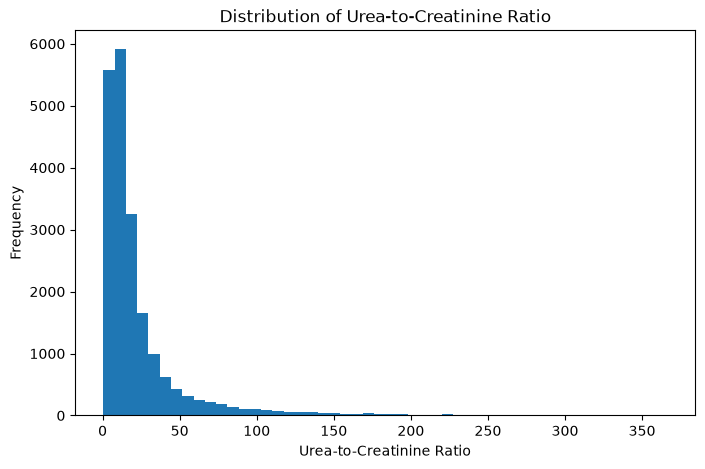

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df_processed['Urea_Creatinine_Ratio'], bins=50)
plt.xlabel('Urea-to-Creatinine Ratio')
plt.ylabel('Frequency')
plt.title('Distribution of Urea-to-Creatinine Ratio')
plt.show()

In [30]:
df_processed['Urea_Creatinine_Ratio'].skew()

np.float64(4.111541801849349)

**Observation**


The histogram shows that the `Urea_Creatinine_Ratio` feature has a strongly right-skewed distribution. Most observations are concentrated at lower ratio values, while a smaller number of observations have much higher values, creating a long right tail.

The calculated skewness is **4.11**, confirming the strong positive skewness of the feature. Despite this distribution, the feature will be retained as a candidate engineered feature and its usefulness will be evaluated during feature selection and model training.

In [31]:
df_processed.columns.tolist()

['Age of the patient',
 'Blood pressure (mm/Hg)',
 'Specific gravity of urine',
 'Albumin in urine',
 'Sugar in urine',
 'Red blood cells in urine',
 'Pus cells in urine',
 'Pus cell clumps in urine',
 'Bacteria in urine',
 'Random blood glucose level (mg/dl)',
 'Blood urea (mg/dl)',
 'Serum creatinine (mg/dl)',
 'Sodium level (mEq/L)',
 'Potassium level (mEq/L)',
 'Hemoglobin level (gms)',
 'Packed cell volume (%)',
 'White blood cell count (cells/cumm)',
 'Red blood cell count (millions/cumm)',
 'Hypertension (yes/no)',
 'Diabetes mellitus (yes/no)',
 'Coronary artery disease (yes/no)',
 'Appetite (good/poor)',
 'Pedal edema (yes/no)',
 'Anemia (yes/no)',
 'Estimated Glomerular Filtration Rate (eGFR)',
 'Urine protein-to-creatinine ratio',
 'Urine output (ml/day)',
 'Serum albumin level',
 'Cholesterol level',
 'Parathyroid hormone (PTH) level',
 'Serum calcium level',
 'Serum phosphate level',
 'Family history of chronic kidney disease',
 'Smoking status',
 'Body Mass Index (BMI)',


### Creating a New Feature – Diabetes and Hypertension Interaction

Diabetes and hypertension are both important health conditions associated with chronic kidney disease. The dataset contains separate variables for these two conditions, but their combined presence may provide additional information for the prediction task.

Therefore, a new binary feature is created to indicate whether a patient has both diabetes and hypertension. This allows the model to directly represent their combined occurrence rather than relying only on the two individual features.

The usefulness of this interaction feature will be evaluated during feature selection and model training.

**Reference:** Zhang et al. (2019), "Synergistic interaction of hypertension and diabetes on chronic kidney disease: Insights from the National Health and Nutrition Examination Survey 1999-2006."

In [32]:
df_processed['Diabetes_Hypertension_Interaction'] = (
    df_processed['Diabetes mellitus (yes/no)'] *
    df_processed['Hypertension (yes/no)']
)

In [33]:
df_processed['Diabetes_Hypertension_Interaction'].value_counts()

Diabetes_Hypertension_Interaction
0    15477
1     5061
Name: count, dtype: int64

### Observation

The `Diabetes_Hypertension_Interaction` feature contains 15,477 records with a value of 0 and 5,061 records with a value of 1.

A value of 1 indicates that both diabetes and hypertension are present, while 0 indicates that both conditions are not present simultaneously. Approximately 24.65% of the records have both conditions.

This feature will be retained as a candidate feature and its contribution to the prediction task will be evaluated during feature selection and model training.

In [34]:
df_processed.head(10)

,Age of the patient,Blood pressure (mm/Hg),Specific gravity of urine,Albumin in urine,Sugar in urine,Red blood cells in urine,Pus cells in urine,Pus cell clumps in urine,Bacteria in urine,Random blood glucose level (mg/dl),...,Cystatin C level,Urinary sediment microscopy results,C-reactive protein (CRP) level,Interleukin-6 (IL-6) level,Target,Physical activity level_high,Physical activity level_low,Physical activity level_moderate,Urea_Creatinine_Ratio,Diabetes_Hypertension_Interaction
0,54,167,1.023,1,4,1,0,0,0,96,...,0.67,1,4.88,10.23,3,0,1,0,22.397532,1
1,42,127,1.023,3,2,1,1,0,1,73,...,0.55,0,4.49,13.11,1,0,0,1,13.704075,0
2,38,148,1.016,0,0,0,1,0,0,77,...,2.37,0,4.57,13.27,3,1,0,0,20.352125,0
3,7,98,1.017,4,0,0,1,0,1,225,...,2.54,0,8.57,12.36,3,1,0,0,11.469890,0
4,67,174,1.015,1,1,1,0,0,0,376,...,1.90,1,6.75,1.46,3,1,0,0,65.511163,0
5,14,92,1.006,4,2,0,0,0,1,371,...,2.81,1,2.33,2.98,3,0,0,1,9.499479,0
6,9,156,1.010,2,0,0,1,0,0,255,...,1.90,0,7.31,7.00,3,0,0,1,41.173591,0
7,67,100,1.010,5,3,1,1,1,1,260,...,0.86,0,7.86,12.95,3,0,0,1,3.128087,0
8,42,138,1.017,4,4,0,1,1,1,352,...,2.24,0,5.93,10.13,3,0,0,1,24.516857,0
9,23,127,1.020,2,4,0,0,0,1,196,...,1.42,0,3.82,6.87,3,0,1,0,7.143558,0


In [35]:
df_processed.tail(10)

,Age of the patient,Blood pressure (mm/Hg),Specific gravity of urine,Albumin in urine,Sugar in urine,Red blood cells in urine,Pus cells in urine,Pus cell clumps in urine,Bacteria in urine,Random blood glucose level (mg/dl),...,Cystatin C level,Urinary sediment microscopy results,C-reactive protein (CRP) level,Interleukin-6 (IL-6) level,Target,Physical activity level_high,Physical activity level_low,Physical activity level_moderate,Urea_Creatinine_Ratio,Diabetes_Hypertension_Interaction
20528,88,139,1.007,0,4,1,0,1,0,350,...,0.80,1,6.74,6.64,3,0,1,0,44.501621,1
20529,68,171,1.024,1,3,1,0,0,0,320,...,2.97,0,5.76,2.12,3,1,0,0,101.028093,0
20530,69,123,1.011,2,1,0,0,1,1,183,...,1.79,0,6.20,1.12,3,0,1,0,25.884460,1
20531,79,146,1.014,1,3,0,0,0,0,398,...,0.54,0,0.58,10.78,1,0,1,0,33.984336,0
20532,56,121,1.022,5,5,0,1,0,1,88,...,2.84,1,7.64,8.65,3,1,0,0,30.950142,0
20533,86,113,1.008,5,3,1,0,0,0,473,...,2.77,1,2.45,9.31,3,0,1,0,9.686187,1
20534,47,80,1.016,3,4,1,0,0,0,477,...,1.81,1,4.19,3.45,3,0,0,1,2.724442,1
20535,89,178,1.011,3,5,0,0,0,0,141,...,1.32,0,5.32,8.39,3,0,1,0,39.193711,1
20536,86,138,1.009,1,5,0,1,0,1,110,...,2.52,0,0.61,9.53,3,0,1,0,30.218229,0
20537,63,120,1.015,4,5,0,0,1,0,256,...,1.03,1,7.00,2.36,3,0,0,1,3.938988,0


In [36]:
df_processed.info()

<class 'pandas.DataFrame'>
RangeIndex: 20538 entries, 0 to 20537
Data columns (total 47 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Age of the patient                           20538 non-null  int64  
 1   Blood pressure (mm/Hg)                       20538 non-null  int64  
 2   Specific gravity of urine                    20538 non-null  float64
 3   Albumin in urine                             20538 non-null  int64  
 4   Sugar in urine                               20538 non-null  int64  
 5   Red blood cells in urine                     20538 non-null  int8   
 6   Pus cells in urine                           20538 non-null  int8   
 7   Pus cell clumps in urine                     20538 non-null  int8   
 8   Bacteria in urine                            20538 non-null  int8   
 9   Random blood glucose level (mg/dl)           20538 non-null  int64  
 10  Blood ure

In [37]:
df_processed.columns.tolist()

['Age of the patient',
 'Blood pressure (mm/Hg)',
 'Specific gravity of urine',
 'Albumin in urine',
 'Sugar in urine',
 'Red blood cells in urine',
 'Pus cells in urine',
 'Pus cell clumps in urine',
 'Bacteria in urine',
 'Random blood glucose level (mg/dl)',
 'Blood urea (mg/dl)',
 'Serum creatinine (mg/dl)',
 'Sodium level (mEq/L)',
 'Potassium level (mEq/L)',
 'Hemoglobin level (gms)',
 'Packed cell volume (%)',
 'White blood cell count (cells/cumm)',
 'Red blood cell count (millions/cumm)',
 'Hypertension (yes/no)',
 'Diabetes mellitus (yes/no)',
 'Coronary artery disease (yes/no)',
 'Appetite (good/poor)',
 'Pedal edema (yes/no)',
 'Anemia (yes/no)',
 'Estimated Glomerular Filtration Rate (eGFR)',
 'Urine protein-to-creatinine ratio',
 'Urine output (ml/day)',
 'Serum albumin level',
 'Cholesterol level',
 'Parathyroid hormone (PTH) level',
 'Serum calcium level',
 'Serum phosphate level',
 'Family history of chronic kidney disease',
 'Smoking status',
 'Body Mass Index (BMI)',


In [38]:
df_processed.shape

(20538, 47)

## 4. Saving the Processed Dataset

In [ ]:
df_processed.to_csv(
    "../../assets/datasets/2_KG_Kidney_Disease_Dataset/data/kidney_disease_processed.csv",
    index=False
)

In [40]:
df_processed.shape

(20538, 47)